# Stage 3 — Multimodal Enrichment + Embeddings (Qwen2.5-VL-3B + SigLIP 2)

Smoke notebook for `scripts/run_enc_vlm_batch_emb_enrich_3b.py`. Runs the full
integrated pipeline (VLM enrichment + SigLIP image/text embeddings in one Ray
Data graph) at N=50. Auto-attaches the Stage 2 LoRA adapter when the smoke
adapter dir is present, else falls back to the base 3B model.

Same code paths as the production job — only N, concurrency, and output paths
are scaled down.

In [1]:
import os, sys, json

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

# MUST be set before importing the script — the LoRA detection runs at
# module-import time. If the dir doesn't exist the script falls back to base 3B.
os.environ.setdefault(
    "QWEN_LORA_ADAPTER_DIR",
    "/mnt/shared_storage/walmart-notebooks/qwen25vl_3b_enrichment_lora_smoke",
)

import ray
if ray.is_initialized():
    ray.shutdown()

ray.init(
    runtime_env={
        "working_dir": os.path.abspath(os.path.join(os.getcwd(), "..")),
    },
)
print("Cluster resources:", json.dumps(ray.cluster_resources(), indent=2))

2026-05-05 06:38:08,371	INFO worker.py:1810 -- Connecting to existing Ray cluster at address: 10.0.187.68:6379...
2026-05-05 06:38:08,398	INFO worker.py:2004 -- Connected to Ray cluster. View the dashboard at https://session-ixqlsdk9cd4drlzxlswjbh934g.i.anyscaleuserdata.com 
2026-05-05 06:38:08,415	INFO packaging.py:691 -- Creating a file package for local module '/home/ray/default_cld_g54aiirwj1s8t9ktgzikqur41k/sa-demos/industry-verticals/ecommerce/vlm-batch-embeddings'.
2026-05-05 06:38:08,432	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_30c4a5e9871e447b.zip' (4.06MiB) to Ray cluster...
2026-05-05 06:38:08,448	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray_pkg_30c4a5e9871e447b.zip'.


Cluster resources: {
  "anyscale/node-group:8CPU-32GB": 1.0,
  "anyscale/provider:aws": 1.0,
  "node:__internal_head__": 1.0,
  "node:10.0.187.68": 1.0,
  "CPU": 8.0,
  "object_store_memory": 9604633804.0,
  "memory": 22410812212.0,
  "anyscale/region:us-west-2": 1.0,
  "anyscale/cpu_only:true": 1.0
}


/home/ray/anaconda3/lib/python3.11/site-packages/ray/_private/worker.py:2052: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


In [2]:
from scripts import run_enc_vlm_batch_emb_enrich_3b as enc

# Smoke overrides — same code paths as the production job, just smaller. We
# rebind module attributes so the script's helpers (build_catalog,
# build_vlm_processor) pick them up at call time via the module globals.
N_SMOKE = 50
enc.N_ROWS = N_SMOKE
enc.VLM_CONCURRENCY = 1
enc.EMB_CONCURRENCY = 1
enc.PROCESS_CONCURRENCY = 4
enc.FETCH_CONCURRENCY = 8
enc.CACHE_PATH = f"{enc.BASE_DIR}/catalog_{enc.CATEGORY}_{N_SMOKE}.parquet"
enc.CHECKPOINT_PATH = f"{enc.BASE_DIR}/enc_vlm_emb_enrich_smoke_{N_SMOKE}_checkpoint"
enc.OUTPUT_PATH = f"{enc.BASE_DIR}/enc_vlm_enriched_with_embeddings_smoke_{N_SMOKE}.parquet"

vlm_mode = (
    f"LoRA: {enc.LORA_ADAPTER_NAME}  (loaded from {enc.LORA_REMOTE_PREFIX})"
    if enc.LORA_ADAPTER_NAME
    else f"base 3B ({enc.VLM_MODEL_SOURCE})"
)
print(f"smoke config: N={N_SMOKE}  VLM_CONCURRENCY={enc.VLM_CONCURRENCY}  EMB_CONCURRENCY={enc.EMB_CONCURRENCY}")
print(f"VLM mode:     {vlm_mode}")
print(f"output:       {enc.OUTPUT_PATH}")

INFO 05-05 06:38:26 [importing.py:44] Triton is installed but 0 active driver(s) found (expected 1). Disabling Triton to prevent runtime errors.
INFO 05-05 06:38:26 [importing.py:68] Triton not installed or not compatible; certain GPU-related functions will not be available.


W0505 06:38:28.618000 11474 site-packages/torch/utils/cpp_extension.py:117] No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'


[vlm] syncing LoRA /mnt/shared_storage/walmart-notebooks/qwen25vl_3b_enrichment_lora_smoke → s3://anyscale-production-data-cld-g54aiirwj1s8t9ktgzikqur41k/org_967t9ah1lbk1yqf1zau6a1v247/cld_g54aiirwj1s8t9ktgzikqur41k/artifact_storage/loras/qwen25vl_3b_enrichment_lora_smoke
[vlm] LoRA adapter ready at s3://anyscale-production-data-cld-g54aiirwj1s8t9ktgzikqur41k/org_967t9ah1lbk1yqf1zau6a1v247/cld_g54aiirwj1s8t9ktgzikqur41k/artifact_storage/loras/qwen25vl_3b_enrichment_lora_smoke; routing batch enrichment requests with model='qwen25vl_3b_enrichment_lora_smoke'
smoke config: N=50  VLM_CONCURRENCY=1  EMB_CONCURRENCY=1
VLM mode:     LoRA: qwen25vl_3b_enrichment_lora_smoke  (loaded from s3://anyscale-production-data-cld-g54aiirwj1s8t9ktgzikqur41k/org_967t9ah1lbk1yqf1zau6a1v247/cld_g54aiirwj1s8t9ktgzikqur41k/artifact_storage/loras)
output:       /mnt/shared_storage/walmart-notebooks/enc_vlm_enriched_with_embeddings_smoke_50.parquet


[load hf] Loading hf://datasets/McAuley-Lab/Amazon-Reviews-2023/raw_meta_Electronics ...


/home/ray/anaconda3/lib/python3.11/site-packages/ray/data/dataset.py:1589: UserWarning: Use 'expr' instead of 'fn' when possible for performant filters.
  warnings.warn(
2026-05-05 06:38:45,268	INFO logging.py:392 -- Registered dataset logger for dataset dataset_7_0
2026-05-05 06:38:45,328	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_7_0. Full logs are in /tmp/ray/session_2026-05-05_06-24-35_736008_3006/logs/ray-data
2026-05-05 06:38:45,329	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_7_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[ReadFiles] -> LimitOperator[limit=50] -> AllToAllOperator[Filter(_has_title_and_image)->Map(_normalize_amazon_row)->Filter(_url_is_reachable)->RandomShuffle] -> TaskPoolMapOperator[Write]
2026-05-05 06:38:45,331	WARNING resource_manager.py:141 -- ⚠️  Ray's object store is configured to use only 42.9% of available memory (8.9GiB out of 20.9GiB total). For optimal Ray Data p

(map pid=12532) [vlm] LoRA adapter ready at s3://anyscale-production-data-cld-g54aiirwj1s8t9ktgzikqur41k/org_967t9ah1lbk1yqf1zau6a1v247/cld_g54aiirwj1s8t9ktgzikqur41k/artifact_storage/loras/qwen25vl_3b_enrichment_lora_1000; routing batch enrichment requests with model='qwen25vl_3b_enrichment_lora_1000'


(map pid=12532) W0505 06:39:09.055000 12532 site-packages/torch/utils/cpp_extension.py:117] No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'
2026-05-05 06:39:11,146	INFO streaming_executor.py:300 -- ✔️  Dataset dataset_7_0 execution finished in 25.82 seconds
INFO:openlineage.client.client:OpenLineageClient will use `composite` transport
INFO:openlineage.client.transport.composite:Stopping OpenLineage CompositeTransport emission after the first successful delivery because `continue_on_success=False`. Transport that emitted the event: <HttpTransport(name=first, kind=http, priority=1)>
2026-05-05 06:39:11,748	INFO dataset.py:5384 -- Data sink Parquet finished. 50 rows and 30.5KiB data written.
2026-05-05 06:39:11,759	INFO logging.py:392 -- Registered dataset logger for dataset dataset_10_0
2026-05-05 06:39:11,766	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_10_0. Full logs are in /tmp/ray/session_2026-05-05_06-24-35_736008_3006/logs/ray-data
2026-05-0

[load hf] cached 50 rows → /mnt/shared_storage/walmart-notebooks/catalog_Electronics_50.parquet

[catalog] 50 rows after filtering

[input row]
  id             = '1070d429975daeea'
  product_id     = 'B01MCZP7RF'
  title          = 'MOSISO Plastic Hard Shell Case & Keyboard Cover Compatible MacBook Air 11 Inch (Models: A1370 & A14
  description    = ''
  image_url      = 'https://m.media-amazon.com/images/I/41mg5gRtN2L._AC_.jpg'
  source         = 'amazon-reviews-2023'


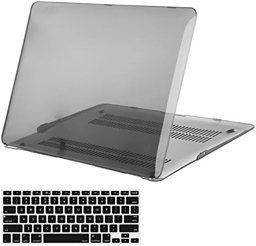

In [3]:
import io as _io
import requests as _r
from PIL import Image as _Image

# build_catalog() caches at CACHE_PATH; first run does the HF read + URL HEAD
# checks, repeat runs reuse the parquet. Returns a Ray Dataset.
ds = enc.build_catalog()
print(f"\n[catalog] {ds.count()} rows after filtering")

row = ds.take(1)[0]
print("\n[input row]")
for k, v in row.items():
    print(f"  {k:14} = {repr(v)[:100]}")

resp = _r.get(row["image_url"], timeout=5, headers={"User-Agent": "anyscale-demo/1.0"})
img = _Image.open(_io.BytesIO(resp.content))
img.thumbnail((256, 256))
img

In [4]:
from ray.data.checkpoint import CheckpointConfig

# CPU fetch + decode + resize
ds = ds.map_batches(
    enc.fetch_and_resize,
    batch_size=16,
    concurrency=enc.FETCH_CONCURRENCY,
    batch_format="numpy",
)

# VLM enrichment via ray.data.llm (vLLM under the hood; LoRA-routed if attached)
ds = enc.build_vlm_processor()(ds)

# SigLIP CPU process — image processor + text tokenizer over title + VLM description
ds = ds.map(
    enc.ProcessSigLIP,
    fn_constructor_kwargs={"model_id": enc.EMB_MODEL_SOURCE},
    num_cpus=1,
    concurrency=enc.PROCESS_CONCURRENCY,
)

# SigLIP GPU embed — pure forward pass on pre-tensorized inputs
ds = ds.map_batches(
    enc.EmbedSigLIP,
    fn_constructor_kwargs={"model_id": enc.EMB_MODEL_SOURCE},
    batch_size=enc.EMB_BATCH_SIZE,
    num_gpus=1,
    concurrency=enc.EMB_CONCURRENCY,
    batch_format="numpy",
)

# Set CheckpointConfig AFTER build_catalog so the catalog's parquet write
# doesn't poison the inference checkpoint with already-seen IDs (would skip
# ~99% of rows on the next run).
ctx = ray.data.DataContext.get_current()
ctx.checkpoint_config = CheckpointConfig(
    id_column="id",
    checkpoint_path=enc.CHECKPOINT_PATH,
    delete_checkpoint_on_success=False,
)

ds.write_parquet(enc.OUTPUT_PATH)
print(f"[done] wrote {enc.OUTPUT_PATH}")

2026-05-05 06:39:17,227	WARNING util.py:624 -- The argument ``concurrency`` is deprecated in Ray 2.51. Please specify argument ``compute`` instead. For more information, see https://docs.ray.io/en/master/data/transforming-data.html#stateful-transforms.
2026-05-05 06:39:17,397	INFO worker.py:1810 -- Connecting to existing Ray cluster at address: 10.0.187.68:6379...
2026-05-05 06:39:17,398	INFO worker.py:1831 -- Calling ray.init() again after it has already been called.
No cloud storage mirror configured


config.json: 0.00B [00:00, ?B/s]

2026-05-05 06:39:25,730	WARNING util.py:624 -- The argument ``concurrency`` is deprecated in Ray 2.51. Please specify argument ``compute`` instead. For more information, see https://docs.ray.io/en/master/data/transforming-data.html#stateful-transforms.
2026-05-05 06:39:25,732	WARNING util.py:624 -- The argument ``concurrency`` is deprecated in Ray 2.51. Please specify argument ``compute`` instead. For more information, see https://docs.ray.io/en/master/data/transforming-data.html#stateful-transforms.
(pid=12918) W0505 06:39:25.666000 12918 site-packages/torch/utils/cpp_extension.py:117] No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'
2026-05-05 06:39:25,744	INFO logging.py:392 -- Registered dataset logger for dataset dataset_24_0
2026-05-05 06:39:25,754	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_24_0. Full logs are in /tmp/ray/session_2026-05-05_06-24-35_736008_3006/logs/ray-data
2026-05-05 06:39:25,754	INFO streaming_executor.py:183 -- Executio

(autoscaler +1m21s) Tip: use `ray status` to view detailed cluster status. To disable these messages, set RAY_SCHEDULER_EVENTS=0.
(autoscaler +1m21s) [autoscaler] [1xL4:8CPU-32GB] Attempting to add 1 node to the cluster (increasing from 0 to 1).
(autoscaler +1m21s) [autoscaler] [1xL4:8CPU-32GB|g6.2xlarge] [us-west-2c] [on-demand] Launched 1 instance.
(autoscaler +1m26s) [autoscaler] [1xL4:8CPU-32GB] Attempting to add 1 node to the cluster (increasing from 1 to 2).
(autoscaler +1m26s) [autoscaler] [1xL4:8CPU-32GB|g6.2xlarge] [us-west-2c] [on-demand] Launched 1 instance.


2026-05-05 06:39:38,792	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_24_0 =======
2026-05-05 06:39:38,798	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-05 06:39:38,798	INFO logging_progress.py:227 -- Active & requested resources: 1/8 CPU, 0.0B/6.7GiB object store (pending: 8 CPU, 2 GPU)
2026-05-05 06:39:38,800	INFO logging_progress.py:181 -- 
2026-05-05 06:39:38,800	INFO logging_progress.py:231 -- ListFiles: 0/1
2026-05-05 06:39:38,801	INFO logging_progress.py:233 --   Tasks: 1; Actors: 0; Queued blocks: 0 (0.0B); Resources: 1.0 CPU, 0.0B object store
2026-05-05 06:39:38,802	INFO logging_progress.py:231 -- ReadFiles: 0/1
2026-05-05 06:39:38,803	INFO logging_progress.py:233 --   Tasks: 0; Actors: 0; Queued blocks: 0 (0.0B); Resources: 0.0 CPU, 0.0B object store
2026-05-05 06:39:38,804	INFO logging_progress.py:231 -- MapBatches(fetch_and_resize): 0/1
2026-05-05 06:39:38,805	INFO logging_progress.py:233 --   Tasks: 0; Actors: 0; Queued blocks: 0 (0.0B); R

...

(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3195, ip=10.0.159.116) INFO 05-05 06:45:53 [loggers.py:257] Engine 000: Avg prompt throughput: 0.0 tokens/s, Avg generation throughput: 143.7 tokens/s, Running: 0 reqs, Waiting: 0 reqs, GPU KV cache usage: 0.0%, Prefix cache hit rate: 0.0%, MM cache hit rate: 0.0%


(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3195, ip=10.0.159.116) [vLLM] Elapsed time for batch 61c970b81fff470eacbfde81c45a202c with size 48: 17.03351797600004
/home/ray/anaconda3/lib/python3.11/site-packages/ray/data/_internal/execution/operators/actor_pool_map_operator.py:452: UserWarning: The minimum number of concurrent actors for 'Map(_postprocess)->Map(ProcessSigLIP)' is set to 4, but the operator only received 1 input(s). This means that the operator can launch at most 1 task(s), and won't fully utilize the available concurrency. You might be able to increase the number of concurrent tasks by configuring `override_num_blocks` earlier in the pipeline.
  warnings.warn(


(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3195, ip=10.0.159.116) ERROR 05-05 06:45:54 [core_client.py:605] Engine core proc EngineCore_DP0 died unexpectedly, shutting down client.
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3195, ip=10.0.159.116) ERROR 05-05 06:45:54 [async_llm.py:693] AsyncLLM output_handler failed.
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3195, ip=10.0.159.116) ERROR 05-05 06:45:54 [async_llm.py:693] Traceback (most recent call last):
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3195, ip=10.0.159.116) ERROR 05-05 06:45:54 [async_llm.py:693]   File "/home/ray/anaconda3/lib/python3.11/site-packages/vllm/v1/engine/async_llm.py", line 649, in output_handler
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3195, ip=10.0.159.116) ERROR 05-05 06:45:54 [async_llm.py:693]     outputs = await engine_core.get_output_async()
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3195, ip=10.0.159.116) ERROR 05-05 06:45:54 [async_llm.py:693]               ^^^^^^^^^^^^^^^^^^

(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3195, ip=10.0.159.116) Exception ignored in: <function vLLMEngineStageUDF.__del__ at 0x7ee90e320d60>
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3195, ip=10.0.159.116) Traceback (most recent call last):
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3195, ip=10.0.159.116)   File "/home/ray/anaconda3/lib/python3.11/site-packages/ray/llm/_internal/batch/stages/vllm_engine_stage.py", line 790, in __del__
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3195, ip=10.0.159.116)   File "/home/ray/anaconda3/lib/python3.11/site-packages/ray/llm/_internal/batch/stages/vllm_engine_stage.py", line 552, in shutdown
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3195, ip=10.0.159.116)   File "/home/ray/anaconda3/lib/python3.11/logging/__init__.py", line 1489, in info
(MapWorker(MapBatches(vLLMEngineStageUDF)) pid=3195, ip=10.0.159.116)   File "/home/ray/anaconda3/lib/python3.11/logging/__init__.py", line 1634, in _log
(MapWorker(MapBatches(vLLMEngineSt

[done] wrote /mnt/shared_storage/walmart-notebooks/enc_vlm_enriched_with_embeddings_smoke_50.parquet


In [6]:
sample = ray.data.read_parquet(enc.OUTPUT_PATH).take(2)
print(f"[output] read back {len(sample)} sample rows from {enc.OUTPUT_PATH}\n")

for r in sample:
    print(json.dumps({
        "title":               r["title"],
        "raw_output":          r["raw_output"],
        "image_embedding[:6]": [round(float(x), 3) for x in r["image_embedding"][:6]],
        "text_embedding[:6]":  [round(float(x), 3) for x in r["text_embedding"][:6]],
    }, indent=2))
    print()

2026-05-05 06:56:39,371	INFO logging.py:392 -- Registered dataset logger for dataset dataset_29_0
2026-05-05 06:56:39,375	INFO streaming_executor.py:182 -- Starting execution of Dataset dataset_29_0. Full logs are in /tmp/ray/session_2026-05-05_06-24-35_736008_3006/logs/ray-data
2026-05-05 06:56:39,375	INFO streaming_executor.py:183 -- Execution plan of Dataset dataset_29_0: InputDataBuffer[Input] -> TaskPoolMapOperator[ListFiles] -> TaskPoolMapOperator[ReadFiles] -> LimitOperator[limit=2]
2026-05-05 06:56:39,390	INFO logging_progress.py:174 -- ======= Running Dataset: dataset_29_0 =======
2026-05-05 06:56:39,391	INFO logging_progress.py:225 -- Total Progress: 0/?
2026-05-05 06:56:39,392	INFO logging_progress.py:227 -- Active & requested resources: 0/8 CPU, 0.0B/6.7GiB object store
2026-05-05 06:56:39,393	INFO logging_progress.py:181 -- 
2026-05-05 06:56:39,393	INFO logging_progress.py:231 -- ListFiles: 0/1
2026-05-05 06:56:39,394	INFO logging_progress.py:233 --   Tasks: 1; Actors: 0; 

2026-05-05 06:56:39,465	INFO streaming_executor.py:300 -- ✔️  Dataset dataset_29_0 execution finished in 0.09 seconds
INFO:openlineage.client.client:OpenLineageClient will use `composite` transport
INFO:openlineage.client.transport.composite:Stopping OpenLineage CompositeTransport emission after the first successful delivery because `continue_on_success=False`. Transport that emitted the event: <HttpTransport(name=first, kind=http, priority=1)>


[output] read back 2 sample rows from /mnt/shared_storage/walmart-notebooks/enc_vlm_enriched_with_embeddings_smoke_50.parquet

{
  "title": "MOSISO Plastic Hard Shell Case & Keyboard Cover Compatible MacBook Air 11 Inch (Models: A1370 & A1465), Transparent Black",
  "raw_output": "```json\n{\n  \"category\": \"Laptop Accessories\",\n  \"attributes\": [\"Hard Shell Case\", \"Keyboard Cover\", \"Transparent Black\"],\n  \"search_tags\": [\"MacBook Air 11\", \"A1370\", \"A1465\", \"Transparent Case\", \"Keyboard Cover\"],\n  \"description\": \"MOSISO Hard Shell Case & Keyboard Cover for MacBook Air 11 inch (A1370 & A1465) in Transparent Black.\"\n}\n```",
  "image_embedding[:6]": [
    -0.003,
    0.008,
    -0.014,
    0.005,
    0.009,
    0.022
  ],
  "text_embedding[:6]": [
    -0.01,
    0.008,
    0.016,
    -0.002,
    -0.003,
    0.002
  ]
}

{
  "title": "Ares Vision Universal mounting CCTV Security Camera Wall Junction Box Bracket with Hidden Compartment (1 Pack, Wall Dome)",
  

In [ ]:
outs = [
  {
    "title": "MOSISO Plastic Hard Shell Case & Keyboard Cover Compatible MacBook Air 11 Inch (Models: A1370 & A1465), Transparent Black",
    "raw_output": {
      "category": "Laptop Accessories",
      "attributes": [
        "Hard Shell Case",
        "Keyboard Cover",
        "Transparent Black"
      ],
      "search_tags": [
        "MacBook Air 11",
        "A1370",
        "A1465",
        "Transparent Case",
        "Keyboard Cover"
      ],
      "description": "MOSISO Hard Shell Case & Keyboard Cover for MacBook Air 11 inch (A1370 & A1465) in Transparent Black."
    },
    "image_embedding[:6]": [
      -0.003,
      0.008,
      -0.014,
      0.005,
      0.009,
      0.022
    ],
    "text_embedding[:6]": [
      -0.01,
      0.008,
      0.016,
      -0.002,
      -0.003,
      0.002
    ]
  },
  {
    "title": "Ares Vision Universal mounting CCTV Security Camera Wall Junction Box Bracket with Hidden Compartment (1 Pack, Wall Dome)",
    "raw_output": {
      "category": "CCTV Security Camera Mounting Bracket",
      "attributes": [
        "Universal Mounting",
        "Wall Junction Box",
        "Hidden Compartment"
      ],
      "search_tags": [
        "CCTV Mounting Bracket",
        "Universal Security Camera Bracket",
        "Wall Junction Box",
        "Hidden Compartment",
        "CCTV Mounting"
      ],
      "description": "Universal CCTV Security Camera Mounting Bracket with Hidden Compartment for Wall Installation"
    },
    "image_embedding[:6]": [
      -0.014,
      -0.003,
      -0.008,
      0.006,
      -0.009,
      0.055
    ],
    "text_embedding[:6]": [
      -0.019,
      0.0,
      0.029,
      -0.002,
      -0.021,
      0.002
    ]
  }
]